## Simple Linear Regression from Scratch

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("1_placement.csv")
df.head()

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57


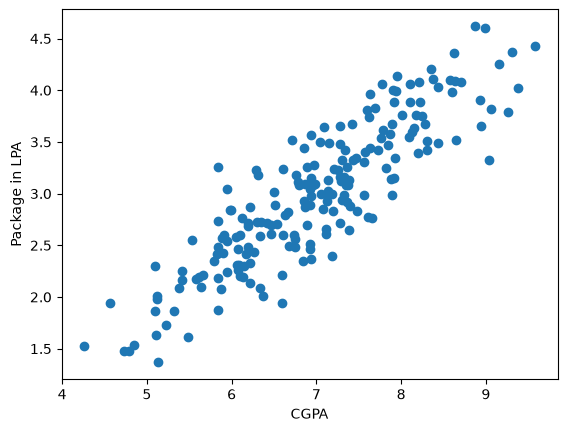

In [3]:
plt.scatter(df["cgpa"], df["package"])
plt.xlabel("CGPA")
plt.ylabel("Package in LPA")
plt.show()

In [4]:
X = df.iloc[:,0:1]
y = df.iloc[:,1]

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=2)

## First Sklearn Implementation
- Sklearn also uses OLS method

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

lr = LinearRegression()

lr.fit(X_train, y_train)

ypred = lr.predict(X_test)

print("R2 Score of Sklearn: ",r2_score(y_test, ypred))

R2 Score of Sklearn:  0.780730147510384


## Now from Scratch

In [21]:
X_train_flat = X_train.values.flatten()
y_train_flat = y_train.values.flatten()
X_test_flat =  X_test.values.flatten()

class MeraLR:
    def __init__(self):
        self.m = None
        self.b = None

    def fit(self, X_train, y_train):
        num = 0
        den = 0
        for i in range(X_train.shape[0]):
            num = num + ((X_train[i] - X_train.mean())*(y_train[i] - y_train.mean()))
            den = den + (X_train[i] - X_train.mean())**2

        self.m = num/den
        self.b = y_train.mean() - (self.m*X_train.mean())

    def predict(self, X_test):
        y_pred = (self.m*X_test) + self.b
        return y_pred

In [22]:
mr = MeraLR()

In [23]:
mr.fit(X_train_flat, y_train_flat)

In [28]:
y_pred = mr.predict(X_test)
 
from sklearn.metrics import r2_score

print("R2 Score: ",r2_score(y_test, y_pred))

R2 Score:  0.7807301475103842
